In [1]:
from datetime import datetime

now = datetime.now()
print(now)

2026-06-27 21:05:22.179191


# 1. Import Library

In [2]:
#Untuk Dataframe
import pandas as pd
import numpy as np

#Untuk Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#Untuk tampilkan waktu sama export model
import time
import joblib

#Ini untuk modeling dari tuning sampai bagi bagi, scalling dkk
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)

#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

#ROC Curve
from sklearn.metrics import RocCurveDisplay

#Untuk import model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Oversampling data train
from imblearn.over_sampling import SMOTE

#XAI sama Os
import shap
import os

# 2. Business Understanding

Industri telekomunikasi menghadapi tantangan besar dalam mempertahankan pelanggan (customer retention), di mana tingkat churn yang tinggi dapat menyebabkan kerugian finansial yang signifikan. Mempertahankan pelanggan yang sudah ada lebih efisien dibandingkan memperoleh pelanggan baru, sehingga perusahaan perlu memahami faktor-faktor yang menyebabkan pelanggan berhenti menggunakan layanan.

Permasalahan utama dalam penelitian ini adalah bagaimana mengidentifikasi pelanggan yang berpotensi churn berdasarkan data historis pelanggan. Dengan memanfaatkan teknik machine learning, perusahaan dapat memprediksi kemungkinan churn secara lebih akurat.

Oleh karena itu, tujuan dari penelitian ini adalah membangun model prediksi churn yang dapat membantu perusahaan dalam mengambil keputusan strategis untuk meningkatkan retensi pelanggan.

# 3. Data Understanding

### 1. Overview Dataset

In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")

df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

Dapat dilihat dataset ini memiliki 7043 baris dan 33 kolum

### 2. Struktur Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Disini tipe data dari variabelnya ada 3 macam, yaitu ada 3 bertipe float64,  6 bertipe int64, 24 bertipe object 

### 3. Cek Missing Value

In [7]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### 4. Identifikasi Target

In [8]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

Disini memilih Churn Value untuk sebagai target dan dapat dilihat 0 (No) ada 5174. dan 1 (Yes) ada 1869. Untuk No adalah Customer yang tetap memilih berlangganan dan yang Yes adalah tidak berlangganan kembali. Sebenarnya disini ada Churn Label cuma karena nanti perlu di encoding jadi langsung pakai Value aja.

### 5. Visualisasi Target

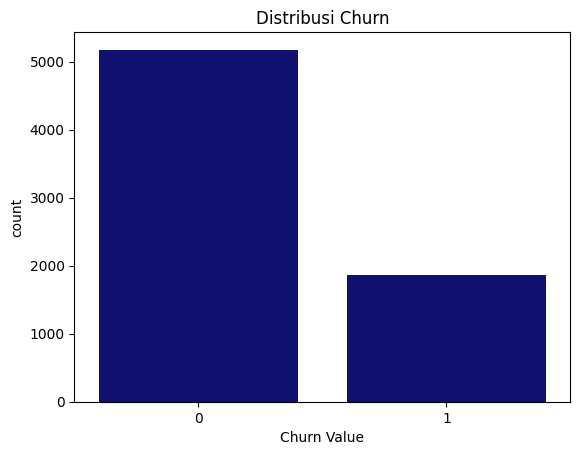

In [9]:
sns.countplot(x='Churn Value', data=df, color='navy')
plt.title('Distribusi Churn') 
plt.show()

### 6. Statistik Deskriptif

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


Disini kita bisa lihat : 
1. Dataset memiliki total 7043 data pelanggan.
2. Rata-rata masa berlangganan pelanggan (Tenure Months) adalah 32 bulan, dengan nilai minimum 0 bulan dan maksimum 72 bulan.
3. Rata-rata biaya bulanan pelanggan (Monthly Charges) sebesar 64.76 dengan rentang nilai antara 18.25 hingga 118.75.
4. Variabel Churn Value memiliki rata-rata sebesar 0.265, yang menunjukkan sekitar 26.5% pelanggan melakukan churn dan sisanya tetap berlangganan.
5. Dataset menunjukkan kondisi ketidakseimbangan kelas (imbalanced data) karena jumlah pelanggan yang tidak churn lebih banyak dibanding pelanggan churn.
6. Nilai rata-rata CLTV (Customer Lifetime Value) sebesar 4400.29 yang menunjukkan variasi nilai pelanggan cukup beragam.

Secara keseluruhan, dataset memiliki variasi data yang baik dan layak digunakan untuk analisis serta pemodelan machine learning prediksi customer churn.

### 7. Histogram

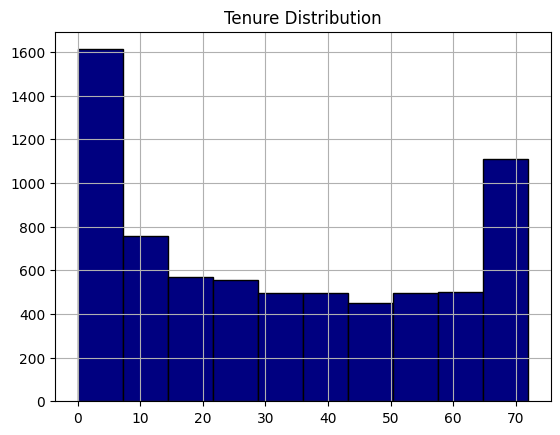

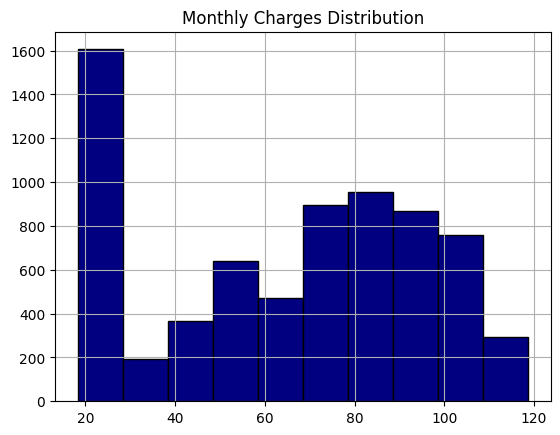

In [11]:
df['Tenure Months'].hist(color='navy', edgecolor='black')
plt.title('Tenure Distribution')
plt.show()

df['Monthly Charges'].hist(color='navy', edgecolor='black')
plt.title('Monthly Charges Distribution')
plt.show()

### 8. Boxplot

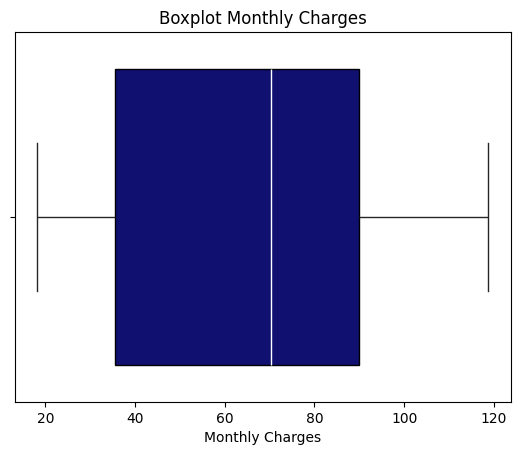

In [12]:
sns.boxplot(x=df['Monthly Charges'], 
            color='navy', 
            boxprops=dict(edgecolor='black'),
            medianprops=dict(color='white'))

plt.title('Boxplot Monthly Charges')
plt.show()

### 9. Hubungan dengan Target

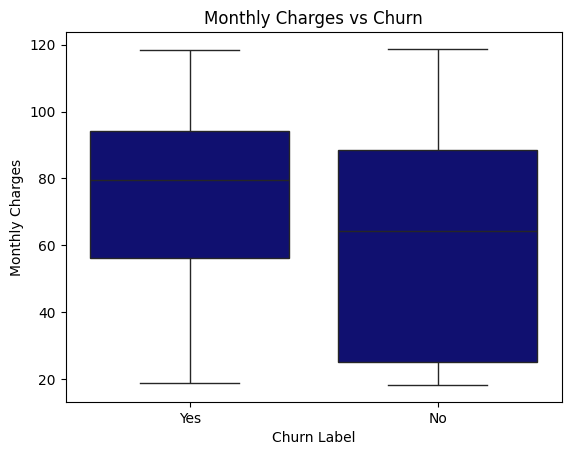

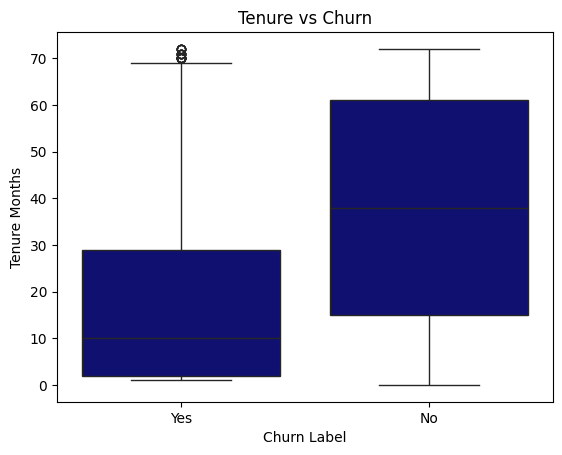

In [13]:
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df, color='navy')
plt.title('Monthly Charges vs Churn')
plt.show()

sns.boxplot(x='Churn Label', y='Tenure Months', data=df, color='navy')
plt.title('Tenure vs Churn')
plt.show()

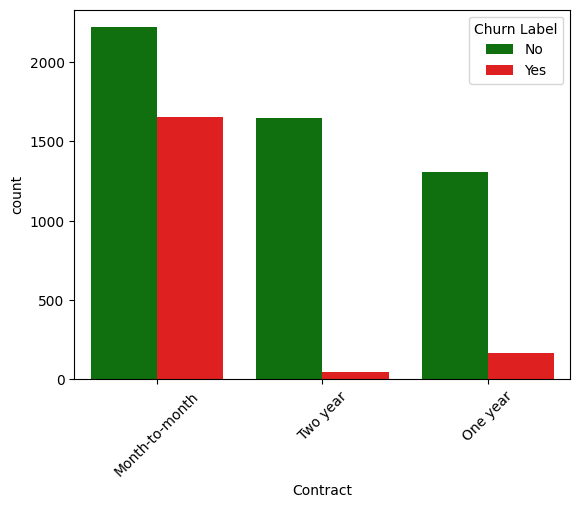

In [14]:
palette = {"Yes": "red", "No": "green"}

sns.countplot(x = 'Contract', hue = 'Churn Label', data = df, palette = palette, hue_order = ["No", "Yes"])

plt.xticks(rotation=45)
plt.show()

### 10. Korelasi

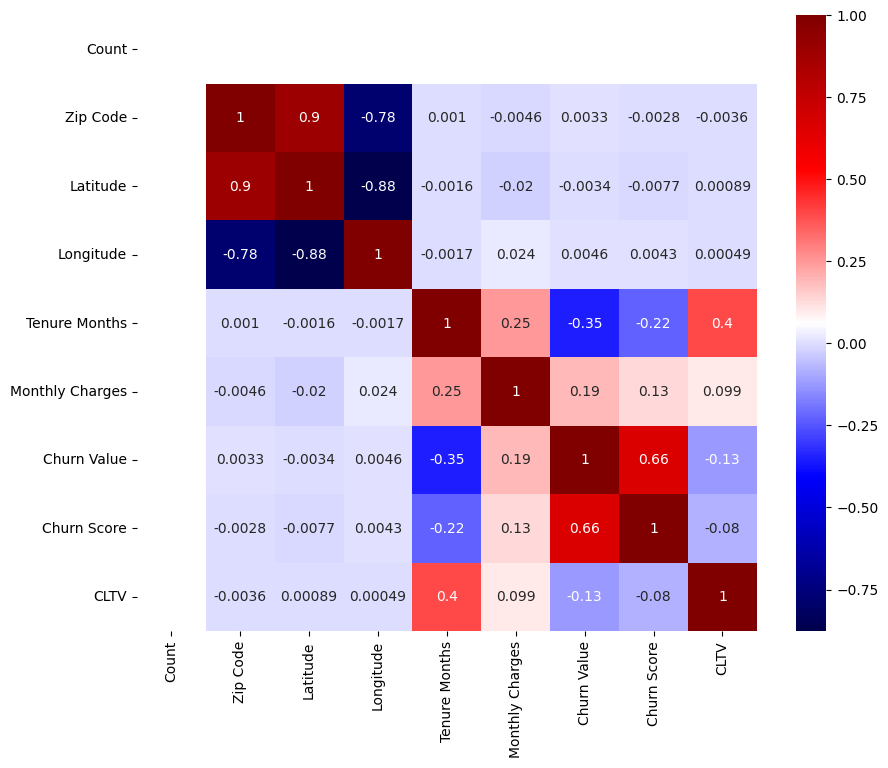

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='seismic')
plt.show()

# 4. Data Preprocessing

### 1. Drop Kolom yang Tidak Dibutuhkan

In [16]:
df = df.drop(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Reason', 'Churn Label']
             , axis = 1)

### 2. Memperbaiki tipe data yang masih object

In [17]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

### 3. Menangani Missing Value

In [18]:
df.isnull().sum()

Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
Churn Score           0
CLTV                  0
dtype: int64

In [19]:
mean_value = df['Total Charges'].mean()

df['Total Charges'] = df['Total Charges'].fillna(mean_value)

Disini menggunakan mean dikarenakan angka null terlalu banyak sehingga menggunakan mean untuk mengisi null tsb

### 4. Menentukan target terlebih dahulu (Split Data)

In [20]:
X = df.drop(['Churn Value'], axis=1)
y = df['Churn Value']

### 5. Mengubah kategorikal menjadi numerikal

In [21]:
cat_cols = X.select_dtypes(include=['object']).columns
print(cat_cols)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')


In [22]:
joblib.dump(X.columns, 'columns.pkl')

['columns.pkl']

Disin mengeluarkan column untuk memastikan ketika nanti di streamlit dapat memanggil kembali dikarenakan sudah diubah numerikal jadi bs manggil balik lagi 

### 6. Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Disini menggunakan perbandingan yang lebih banyak dipakai pada penelitian sebelumnya yaitu 80:20

In [24]:
train_data = X_train.copy()
train_data['Churn Value'] = y_train.values

test_data = X_test.copy()
test_data['Churn Value'] = y_test.values

train_data.to_csv("train_dataset.csv", index=False)
test_data.to_csv("test_dataset.csv", index=False)

print("Train dataset berhasil diekspor.")
print("Test dataset berhasil diekspor.")

Train dataset berhasil diekspor.
Test dataset berhasil diekspor.


### Misahin Data training dan Testing

### 7. Scaling Data

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Scaler butuh diekspor dikarenakan untuk memastikan format dalam konversi input baru bisa disesuaikan ketika pada proses deployment streamlit

# 5. Modelling

## 1. Base Model

In [27]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

#Ini buat menampung hasil
results_baseline = {}

#Looping Model
for name, model in models.items():
    
    #ini untuk training dan mencatat waktunya 
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    #Buat testing sekalian catat waktu
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    #Probabilities (untuk ROC AUC)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_prob)

    #Metric tambahan
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    #Print hasil
    print(f"\n{name} - Baseline")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")

    #Simpan hasil
    results_baseline[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }


Logistic Regression - Baseline
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1035
           1       0.84      0.86      0.85       374

    accuracy                           0.92      1409
   macro avg       0.89      0.90      0.90      1409
weighted avg       0.92      0.92      0.92      1409

ROC-AUC: 0.9745
Training Time: 0.1249 seconds
Testing Time: 0.0010 seconds

KNN - Baseline
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1035
           1       0.76      0.72      0.74       374

    accuracy                           0.87      1409
   macro avg       0.83      0.82      0.83      1409
weighted avg       0.86      0.87      0.87      1409

ROC-AUC: 0.9050
Training Time: 0.0045 seconds
Testing Time: 4.4229 seconds

Naive Bayes - Baseline
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      1035
           1   

In [28]:
#Permudah lihat output
results_df = pd.DataFrame(results_baseline).T
results_df = results_df.round(4)

print("\nPerbandingan Model Baseline")
display(results_df)


Perbandingan Model Baseline


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Test Time (s)
Logistic Regression,0.9177,0.8359,0.8583,0.8470,0.9745,0.1249,0.0010
KNN,0.8666,0.7627,0.7219,0.7418,0.9050,0.0045,4.4229
Naive Bayes,0.8112,0.5985,0.8770,0.7115,0.8968,0.0071,0.0014
Random Forest,0.9297,0.8726,0.8610,0.8668,0.9719,3.0846,0.1173
XGBoost,0.9241,0.8618,0.8503,0.8560,0.9807,0.3245,0.0060


## Baseline Model Evaluation

### Logistic Regression
- Accuracy: **91.77%**
- ROC-AUC: **97.45%**
- Precision dan Recall relatif seimbang, menghasilkan F1-Score sebesar **84.70%**.
- Memberikan performa yang kompetitif dengan waktu pelatihan yang sangat cepat.

### K-Nearest Neighbors (KNN)
- Accuracy: **86.66%**
- Memiliki performa lebih rendah dibandingkan model lainnya.
- Waktu pelatihan sangat cepat, namun waktu pengujian paling lama karena proses prediksi bergantung pada pencarian tetangga terdekat.

### Naive Bayes
- Accuracy: **81.12%**
- Memiliki Recall tertinggi (**87.70%**) sehingga mampu mendeteksi lebih banyak pelanggan churn.
- Precision terendah (**59.85%**) menunjukkan jumlah false positive yang relatif tinggi.

### Random Forest
- Accuracy tertinggi (**92.97%**).
- Precision (**87.26%**) dan F1-Score (**86.68%**) tertinggi di antara seluruh model.
- Menunjukkan performa klasifikasi yang paling seimbang pada tahap baseline.

### XGBoost
- Accuracy: **92.41%**
- ROC-AUC tertinggi (**98.07%**) menunjukkan kemampuan diskriminasi kelas yang sangat baik.
- Menjadi salah satu model dengan performa terbaik pada evaluasi baseline.

### Summary
- **Random Forest** memberikan performa keseluruhan terbaik berdasarkan Accuracy, Precision, dan F1-Score.
- **XGBoost** menghasilkan nilai ROC-AUC tertinggi sehingga memiliki kemampuan membedakan kelas churn dan non-churn yang sangat baik.
- **Logistic Regression** tetap menunjukkan performa yang kompetitif dengan efisiensi komputasi yang tinggi.
- **KNN** memiliki performa paling rendah setelah Logistic Regression dan membutuhkan waktu prediksi paling lama.
- **Naive Bayes** menghasilkan Recall tertinggi, namun Precision yang rendah menunjukkan kecenderungan menghasilkan lebih banyak false positive.

## 2. SMOTE 

### 1. Penanganan Imbalance

In [29]:
print("Sebelum SMOTE:")
print(y_train.value_counts())

Sebelum SMOTE:
Churn Value
0    4139
1    1495
Name: count, dtype: int64


In [30]:
smote = SMOTE(sampling_strategy={0: 5000, 1: 5000}, random_state=42, k_neighbors=5)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nSetelah SMOTE :")
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True))


Setelah SMOTE :
Churn Value
0    5000
1    5000
Name: count, dtype: int64
Churn Value
0    0.5
1    0.5
Name: proportion, dtype: float64


### 2. Modelling

In [31]:
#MODEL WITH SMOTE
results_smote = {}

for name, model in models.items():
    
    #Training pakai data SMOTE
    start_train = time.time()
    model.fit(X_train_smote, y_train_smote)
    train_time = time.time() - start_train

    #Testing tetap pakai test asli
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    #Probability ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_prob)

    #Metric tambahan
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    #Output detail
    print(f"\n{name} - WITH SMOTE")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Testing Time: {test_time:.4f} seconds")

    #Simpan hasil
    results_smote[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }


Logistic Regression - WITH SMOTE
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.79      0.91      0.84       374

    accuracy                           0.91      1409
   macro avg       0.88      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409

ROC-AUC: 0.9740
Training Time: 0.0845 seconds
Testing Time: 0.0000 seconds

KNN - WITH SMOTE
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1035
           1       0.59      0.86      0.70       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.78      1409
weighted avg       0.85      0.80      0.81      1409

ROC-AUC: 0.8866
Training Time: 0.0067 seconds
Testing Time: 0.4737 seconds

Naive Bayes - WITH SMOTE
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1035
         

In [32]:
#Permudah lihat hasil
results_smote_df = pd.DataFrame(results_smote).T
results_smote_df = results_smote_df.round(4)

print("\nPerbandingan Model WITH SMOTE")
display(results_smote_df)


Perbandingan Model WITH SMOTE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Test Time (s)
Logistic Regression,0.9113,0.7889,0.9091,0.8447,0.9740,0.0845,0.0000
KNN,0.8034,0.5890,0.8583,0.6986,0.8866,0.0067,0.4737
Naive Bayes,0.8233,0.6214,0.8556,0.7199,0.8999,0.0151,0.0020
Random Forest,0.9262,0.8342,0.9011,0.8663,0.9710,5.3253,0.1151
XGBoost,0.9233,0.8500,0.8636,0.8568,0.9794,0.9182,0.0035


## Model Evaluation with SMOTE

### Logistic Regression
- Accuracy sedikit menurun menjadi **91.13%** dibandingkan baseline.
- Recall meningkat menjadi **90.91%**, menunjukkan lebih banyak pelanggan churn berhasil terdeteksi.
- Precision menurun menjadi **78.89%**, menandakan peningkatan false positive.
- ROC-AUC tetap tinggi (**97.40%**), sehingga kemampuan diskriminasi model tetap baik.

### K-Nearest Neighbors (KNN)
- Accuracy menurun menjadi **80.34%**.
- Recall meningkat menjadi **85.83%**, namun Precision turun menjadi **58.90%**.
- F1-Score menurun dibandingkan baseline.
- Menunjukkan bahwa SMOTE kurang mampu meningkatkan performa KNN secara keseluruhan.

### Naive Bayes
- Accuracy meningkat menjadi **82.33%** dibandingkan baseline.
- Recall tetap tinggi (**85.56%**) sehingga masih mampu mendeteksi sebagian besar pelanggan churn.
- Precision meningkat menjadi **62.14%**, menunjukkan sedikit pengurangan false positive.
- Menjadi satu-satunya model yang mengalami peningkatan Accuracy setelah penerapan SMOTE.

### Random Forest
- Accuracy sedikit menurun menjadi **92.62%**.
- Recall meningkat menjadi **90.11%**, menunjukkan kemampuan deteksi churn yang lebih baik.
- Precision menurun menjadi **83.42%** akibat bertambahnya prediksi positif.
- F1-Score tetap stabil (**86.63%**), sehingga Random Forest masih menjadi salah satu model dengan performa paling seimbang.

### XGBoost
- Accuracy relatif stabil pada **92.33%**.
- Precision (**85.00%**) dan Recall (**86.36%**) tetap seimbang.
- ROC-AUC tetap sangat tinggi (**97.94%**).
- Menunjukkan bahwa XGBoost tetap mempertahankan performa yang baik setelah penerapan SMOTE.

### Summary
- Penerapan SMOTE secara umum berhasil meningkatkan **Recall** pada sebagian besar model sehingga kemampuan mendeteksi pelanggan churn menjadi lebih baik.
- Sebagian besar model mengalami penurunan **Precision**, menunjukkan adanya peningkatan jumlah false positive sebagai konsekuensi dari proses oversampling.
- **Random Forest** dan **XGBoost** tetap memberikan performa paling stabil setelah penerapan SMOTE.
- **Naive Bayes** merupakan satu-satunya model yang mengalami peningkatan Accuracy dibandingkan hasil baseline.
- Hasil ini menunjukkan bahwa SMOTE lebih efektif dalam meningkatkan kemampuan deteksi kelas minoritas dibandingkan meningkatkan Accuracy secara keseluruhan.

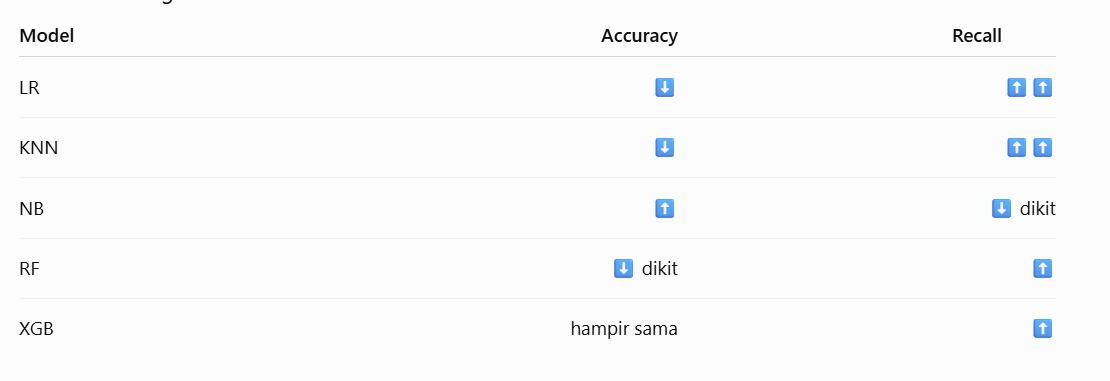

## 3. SMOTE + Tuning

#### 1. XGBoost Tuning

In [33]:
#Manggil model XGBoost
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

#Parameter Grid untuk XGboost
param_grid_xgb = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.8, 1], 'colsample_bytree': [0.8, 1]}

#Tuning Menggunakan GridSearchCV
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Catat Waktu Tuning
start_tuning = time.time()
grid_xgb.fit(X_train_smote, y_train_smote)
tuning_time = time.time() - start_tuning

#Buat Simpan Best Model
best_xgb = grid_xgb.best_estimator_

#Output parameter terbaik
print("Best Params XGB:", grid_xgb.best_params_)
print("Best CV Score XGB:", grid_xgb.best_score_)
print(f"Tuning Time: {tuning_time:.4f} seconds")

#Testing
start_test = time.time()
y_pred_xgb = best_xgb.predict(X_test)
test_time = time.time() - start_test

# Probability ROC-AUC
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Metric evaluasi
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

#Evaluasi XGBoost
print("\nXGBoost AFTER TUNING + SMOTE")

print(classification_report(y_test, y_pred_xgb))

print(f"Accuracy: {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall: {rec_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_xgb:.4f}")

print(f"Tuning Time: {tuning_time:.4f} seconds")
print(f"Testing Time: {test_time:.4f} seconds")

#Simpan hasil XGBoost
xgb_tuned_results = {
    "Accuracy": acc_xgb,
    "Precision": prec_xgb,
    "Recall": rec_xgb,
    "F1-Score": f1_xgb,
    "ROC-AUC": roc_xgb,
    "Tuning Time (s)": tuning_time,
    "Test Time (s)": test_time
}

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Params XGB: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score XGB: 0.9469755041626963
Tuning Time: 160.5533 seconds

XGBoost AFTER TUNING + SMOTE
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1035
           1       0.85      0.87      0.86       374

    accuracy                           0.93      1409
   macro avg       0.90      0.91      0.91      1409
weighted avg       0.93      0.93      0.93      1409

Accuracy: 0.9255
Precision: 0.8494
Recall: 0.8743
F1-Score: 0.8617
ROC-AUC: 0.9803
Tuning Time: 160.5533 seconds
Testing Time: 0.0111 seconds


In [34]:
joblib.dump(best_xgb, 'xgboost_tuning.pkl')

['xgboost_tuning.pkl']

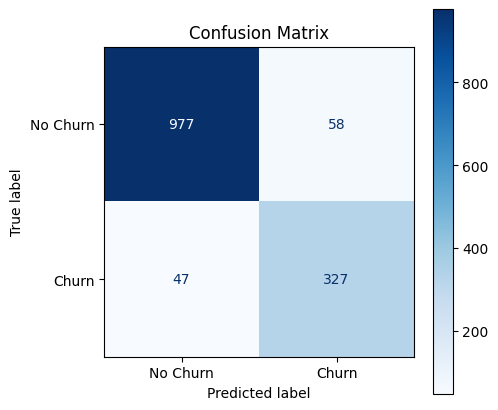

In [35]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

#### 2. Random Forest Tuning

In [36]:
#Parameter Random Forest
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10],  'min_samples_leaf': [1, 2, 4]}

#Tuning menggunakan GridSearchCV
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Catat Waktu tuning
start_tuning = time.time()
grid.fit(X_train_smote, y_train_smote)
tuning_time = time.time() - start_tuning

#Menampilkan best model
best_rf = grid.best_estimator_

#Output parameter terbaik
print("Best Params:", grid.best_params_)
print("Best CV Score (F1):", grid.best_score_)
print(f"Tuning Time: {tuning_time:.4f} seconds")

#Testing
start_test = time.time()
y_pred = best_rf.predict(X_test)
test_time = time.time() - start_test

#Probability untuk ROC-AUC
y_prob = best_rf.predict_proba(X_test)[:, 1]

#Metric evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\nRandom Forest (TUNED + SMOTE)")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")

print(f"Tuning Time: {tuning_time:.4f} seconds")
print(f"Testing Time: {test_time:.4f} seconds")

#Simpan hasil Tuning
rf_tuned_results = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-Score": f1,
    "ROC-AUC": roc,
    "Tuning Time (s)": tuning_time,
    "Test Time (s)": test_time
}

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (F1): 0.9541429861192839
Tuning Time: 331.4235 seconds

Random Forest (TUNED + SMOTE)
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1035
           1       0.83      0.90      0.87       374

    accuracy                           0.93      1409
   macro avg       0.90      0.92      0.91      1409
weighted avg       0.93      0.93      0.93      1409

Accuracy: 0.9262
Precision: 0.8342
Recall: 0.9011
F1-Score: 0.8663
ROC-AUC: 0.9710
Tuning Time: 331.4235 seconds
Testing Time: 0.0512 seconds


In [37]:
joblib.dump(best_rf, 'random_forest_model.pkl')

['random_forest_model.pkl']

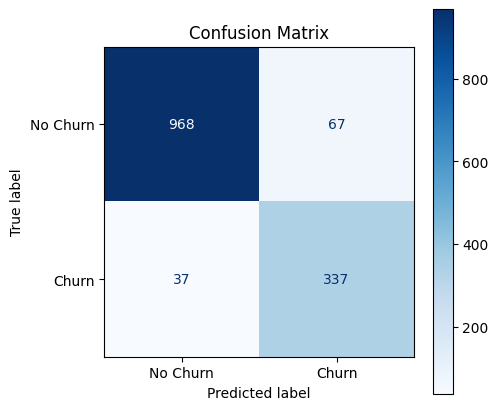

In [38]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

#### 3 Logistic Regression Tuning

In [39]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

#Parameter Grid untuk Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

#Tuning Menggunakan GridSearchCV
grid_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Catat Waktu Tuning
start_tuning = time.time()
grid_lr.fit(X_train_smote, y_train_smote)
tuning_time_lr = time.time() - start_tuning

#Buat Simpan Best Model
best_lr = grid_lr.best_estimator_

#Output parameter terbaik
print("Best Params Logistic Regression:", grid_lr.best_params_)
print("Best CV Score Logistic Regression:", grid_lr.best_score_)
print(f"Tuning Time: {tuning_time_lr:.4f} seconds")

#Testing
start_test = time.time()
y_pred_lr = best_lr.predict(X_test)
test_time_lr = time.time() - start_test

#Probability ROC-AUC
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

#Metric evaluasi
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

#Evaluasi Logistic Regression
print("\nLogistic Regression AFTER TUNING + SMOTE")
print(classification_report(y_test, y_pred_lr))

print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall: {rec_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"ROC-AUC: {roc_lr:.4f}")

print(f"Tuning Time: {tuning_time_lr:.4f} seconds")
print(f"Testing Time: {test_time_lr:.4f} seconds")

#Simpan hasil Logistic Regression
lr_tuned_results = {
    "Accuracy": acc_lr,
    "Precision": prec_lr,
    "Recall": rec_lr,
    "F1-Score": f1_lr,
    "ROC-AUC": roc_lr,
    "Tuning Time (s)": tuning_time_lr,
    "Test Time (s)": test_time_lr
}

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params Logistic Regression: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score Logistic Regression: 0.928765320234718
Tuning Time: 1.6005 seconds

Logistic Regression AFTER TUNING + SMOTE
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1035
           1       0.79      0.91      0.84       374

    accuracy                           0.91      1409
   macro avg       0.88      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409

Accuracy: 0.9113
Precision: 0.7889
Recall: 0.9091
F1-Score: 0.8447
ROC-AUC: 0.9737
Tuning Time: 1.6005 seconds
Testing Time: 0.0011 seconds


In [40]:
joblib.dump(best_lr, 'lr_tuning.pkl')

['lr_tuning.pkl']

#### 4. KNN Tuning

In [41]:
#Manggil model KNN
knn_model = KNeighborsClassifier()

#Parameter Grid untuk KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#Tuning Menggunakan GridSearchCV
grid_knn = GridSearchCV(estimator=knn_model, param_grid=param_grid_knn, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Catat Waktu Tuning
start_tuning = time.time()
grid_knn.fit(X_train_smote, y_train_smote)
tuning_time_knn = time.time() - start_tuning

#Buat Simpan Best Model
best_knn = grid_knn.best_estimator_

#Output parameter terbaik
print("Best Params KNN:", grid_knn.best_params_)
print("Best CV Score KNN:", grid_knn.best_score_)
print(f"Tuning Time: {tuning_time_knn:.4f} seconds")

#Testing
start_test = time.time()
y_pred_knn = best_knn.predict(X_test)
test_time_knn = time.time() - start_test

#Probability ROC-AUC
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

#Metric evaluasi
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)

#Evaluasi KNN
print("\nKNN AFTER TUNING + SMOTE")
print(classification_report(y_test, y_pred_knn))

print(f"Accuracy: {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall: {rec_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"ROC-AUC: {roc_knn:.4f}")

print(f"Tuning Time: {tuning_time_knn:.4f} seconds")
print(f"Testing Time: {test_time_knn:.4f} seconds")

#Simpan hasil KNN
knn_tuned_results = {
    "Accuracy": acc_knn,
    "Precision": prec_knn,
    "Recall": rec_knn,
    "F1-Score": f1_knn,
    "ROC-AUC": roc_knn,
    "Tuning Time (s)": tuning_time_knn,
    "Test Time (s)": test_time_knn
}

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Score KNN: 0.927662338013676
Tuning Time: 19.8435 seconds

KNN AFTER TUNING + SMOTE
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      1035
           1       0.62      0.78      0.69       374

    accuracy                           0.81      1409
   macro avg       0.76      0.80      0.78      1409
weighted avg       0.83      0.81      0.82      1409

Accuracy: 0.8126
Precision: 0.6160
Recall: 0.7807
F1-Score: 0.6887
ROC-AUC: 0.8641
Tuning Time: 19.8435 seconds
Testing Time: 0.5076 seconds


In [42]:
joblib.dump(best_knn, 'knn_tuning.pkl')

['knn_tuning.pkl']

#### 5. NB Tuning

In [43]:
#Manggil model Naive Bayes
nb_model = GaussianNB()

#Parameter Grid untuk Naive Bayes
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

#Tuning Menggunakan GridSearchCV
grid_nb = GridSearchCV(estimator=nb_model, param_grid=param_grid_nb, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Catat Waktu Tuning
start_tuning = time.time()
grid_nb.fit(X_train_smote, y_train_smote)
tuning_time_nb = time.time() - start_tuning

#Buat Simpan Best Model
best_nb = grid_nb.best_estimator_

#Output parameter terbaik
print("Best Params Naive Bayes:", grid_nb.best_params_)
print("Best CV Score Naive Bayes:", grid_nb.best_score_)
print(f"Tuning Time: {tuning_time_nb:.4f} seconds")

#Testing
start_test = time.time()
y_pred_nb = best_nb.predict(X_test)
test_time_nb = time.time() - start_test

#Probability ROC-AUC
y_prob_nb = best_nb.predict_proba(X_test)[:, 1]

#Metric evaluasi
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_nb = roc_auc_score(y_test, y_prob_nb)

#Evaluasi Naive Bayes
print("\nNaive Bayes AFTER TUNING + SMOTE")
print(classification_report(y_test, y_pred_nb))

print(f"Accuracy: {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall: {rec_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print(f"ROC-AUC: {roc_nb:.4f}")

print(f"Tuning Time: {tuning_time_nb:.4f} seconds")
print(f"Testing Time: {test_time_nb:.4f} seconds")

#Simpan hasil Naive Bayes
nb_tuned_results = {
    "Accuracy": acc_nb,
    "Precision": prec_nb,
    "Recall": rec_nb,
    "F1-Score": f1_nb,
    "ROC-AUC": roc_nb,
    "Tuning Time (s)": tuning_time_nb,
    "Test Time (s)": test_time_nb
}

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params Naive Bayes: {'var_smoothing': 1e-12}
Best CV Score Naive Bayes: 0.8489123678594067
Tuning Time: 0.4641 seconds

Naive Bayes AFTER TUNING + SMOTE
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1035
           1       0.62      0.86      0.72       374

    accuracy                           0.82      1409
   macro avg       0.78      0.83      0.80      1409
weighted avg       0.86      0.82      0.83      1409

Accuracy: 0.8233
Precision: 0.6214
Recall: 0.8556
F1-Score: 0.7199
ROC-AUC: 0.8999
Tuning Time: 0.4641 seconds
Testing Time: 0.0025 seconds


In [44]:
joblib.dump(best_nb, 'nb_tuning.pkl')

['nb_tuning.pkl']

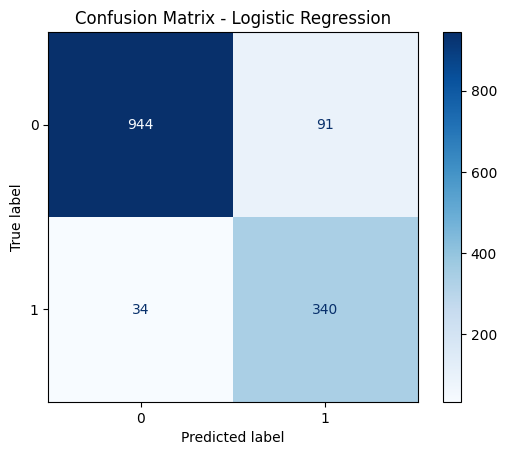

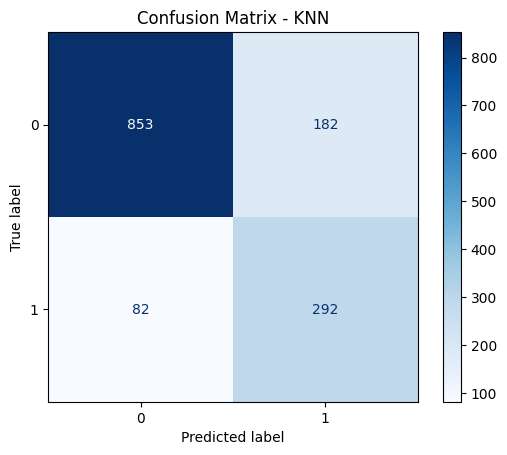

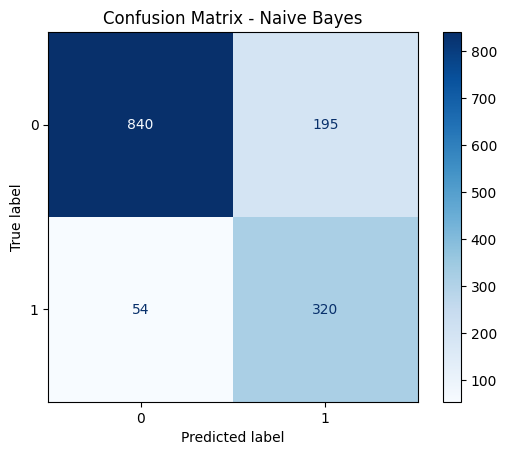

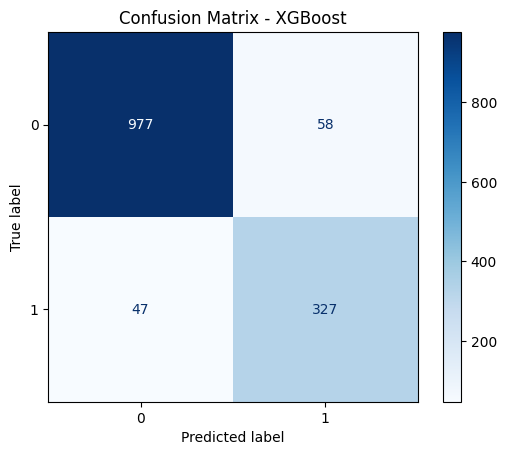

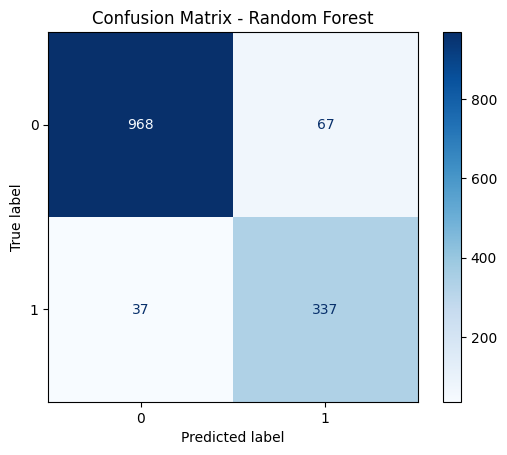

In [45]:
#Daftar model hasil tuning
tuned_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Naive Bayes": best_nb,
    "XGBoost": best_xgb,
    "Random Forest": best_rf
}

#Confusion Matrix untuk setiap model
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

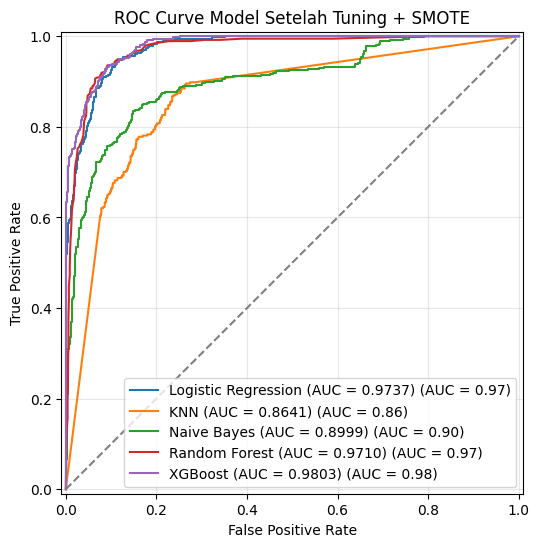

In [46]:
from sklearn.metrics import RocCurveDisplay

#Daftar model hasil tuning
tuned_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Naive Bayes": best_nb,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

#Plot ROC Curve
plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=f"{name} (AUC = {roc_auc:.4f})",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve Model Setelah Tuning + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### 4. Comparison Table 

In [47]:
comparison_tuned = pd.DataFrame({"Logistic Regression": lr_tuned_results, "KNN": knn_tuned_results, "Naive Bayes": nb_tuned_results, "Random Forest": rf_tuned_results, "XGBoost": xgb_tuned_results}).T

#Bulatkan angka
comparison_tuned = comparison_tuned.round(4)

#Tampilkan hasil
print("Perbandingan Model Setelah Tuning + SMOTE")

display(comparison_tuned)

Perbandingan Model Setelah Tuning + SMOTE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tuning Time (s),Test Time (s)
Logistic Regression,0.9113,0.7889,0.9091,0.8447,0.9737,1.6005,0.0011
KNN,0.8126,0.6160,0.7807,0.6887,0.8641,19.8435,0.5076
Naive Bayes,0.8233,0.6214,0.8556,0.7199,0.8999,0.4641,0.0025
Random Forest,0.9262,0.8342,0.9011,0.8663,0.9710,331.4235,0.0512
XGBoost,0.9255,0.8494,0.8743,0.8617,0.9803,160.5533,0.0111


Setelah dilakukan hyperparameter tuning dan penerapan SMOTE, model Random Forest menghasilkan performa terbaik dengan accuracy sebesar 92.62%, recall sebesar 90.11%, dan F1-score sebesar 86.63%.


Tingginya nilai recall pada Random Forest menunjukkan bahwa model mampu mendeteksi pelanggan churn lebih baik dibandingkan model lainnya, sehingga cocok digunakan pada kasus customer churn prediction.


Model XGBoost memperoleh nilai ROC-AUC tertinggi sebesar 0.9803, yang menunjukkan kemampuan sangat baik dalam membedakan pelanggan churn dan non-churn.


Selain memiliki ROC-AUC tertinggi, XGBoost juga menunjukkan efisiensi komputasi yang lebih baik dibandingkan Random Forest dengan tuning time sebesar 148.55 detik dan testing time sebesar 0.0175 detik.


Model SVM menghasilkan performa paling rendah dibandingkan model lainnya dengan accuracy sebesar 89.92%, recall sebesar 80.21%, dan F1-score sebesar 80.86%.


Waktu tuning Random Forest menjadi yang paling lama yaitu 476.17 detik karena banyaknya kombinasi parameter yang diuji pada proses GridSearchCV.


Hyperparameter tuning tidak memberikan peningkatan performa yang sangat signifikan pada Random Forest, namun mampu mempertahankan performa tinggi dengan recall terbaik dibandingkan model lainnya.


Secara keseluruhan, Random Forest dipilih sebagai model terbaik karena memiliki performa klasifikasi paling seimbang, khususnya dalam mendeteksi pelanggan churn yang ditunjukkan oleh nilai recall dan F1-score tertinggi.



### 5. Final Tuning RF

Karena RF merupakan hasil model terbailk disini melakukan tuning terakhir dengan melakukan persempit parameter

In [48]:
param_grid_final = {'n_estimators': [150, 200, 250, 300], 'max_depth': [15, 20, 25], 'min_samples_split': [2, 3, 5], 'min_samples_leaf': [1, 2]}

#Tuning Gridsearch final
grid_final_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_final, cv=3, scoring='f1', n_jobs=-1, verbose=2)

#Tuning
start_tuning = time.time()
grid_final_rf.fit(X_train_smote, y_train_smote)
tuning_time = time.time() - start_tuning

#Best Final Model
best_final_rf = grid_final_rf.best_estimator_

print("Best Final Params:", grid_final_rf.best_params_)
print("Best Final CV Score:", grid_final_rf.best_score_)
print(f"Final Tuning Time: {tuning_time:.4f} seconds")

#Testing
start_test = time.time()
y_pred_final = best_final_rf.predict(X_test)
test_time = time.time() - start_test

#Probability ROC-AUC
y_prob_final = best_final_rf.predict_proba(X_test)[:, 1]

#Metrik Evaluasi
acc_final = accuracy_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final)
rec_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_final = roc_auc_score(y_test, y_prob_final)

# Hasil Evaluasi
print("\nFINAL RANDOM FOREST + SMOTE")

print(classification_report(y_test, y_pred_final))

print(f"Accuracy: {acc_final:.4f}")
print(f"Precision: {prec_final:.4f}")
print(f"Recall: {rec_final:.4f}")
print(f"F1-Score: {f1_final:.4f}")
print(f"ROC-AUC: {roc_final:.4f}")

print(f"Tuning Time: {tuning_time:.4f} seconds")
print(f"Testing Time: {test_time:.4f} seconds")

#Simpan model final
final_rf_results = {
    "Accuracy": acc_final,
    "Precision": prec_final,
    "Recall": rec_final,
    "F1-Score": f1_final,
    "ROC-AUC": roc_final,
    "Tuning Time (s)": tuning_time,
    "Test Time (s)": test_time
}

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Final Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best Final CV Score: 0.9533703676104938
Final Tuning Time: 251.4324 seconds

FINAL RANDOM FOREST + SMOTE
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1035
           1       0.84      0.90      0.87       374

    accuracy                           0.93      1409
   macro avg       0.90      0.92      0.91      1409
weighted avg       0.93      0.93      0.93      1409

Accuracy: 0.9276
Precision: 0.8366
Recall: 0.9037
F1-Score: 0.8689
ROC-AUC: 0.9724
Tuning Time: 251.4324 seconds
Testing Time: 0.0298 seconds


In [49]:
joblib.dump(best_final_rf, 'randomforest_final.pkl')

['randomforest_final.pkl']

In [50]:
final_rf_df = pd.DataFrame({"Final Random Forest + SMOTE": final_rf_results}).T

# Bulatkan angka
final_rf_df = final_rf_df.round(4)

# Tampilkan dataframe
print("Hasil Final Model Random Forest + SMOTE")

display(final_rf_df)

Hasil Final Model Random Forest + SMOTE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tuning Time (s),Test Time (s)
Final Random Forest + SMOTE,0.9276,0.8366,0.9037,0.8689,0.9724,251.4324,0.0298


<Figure size 700x500 with 0 Axes>

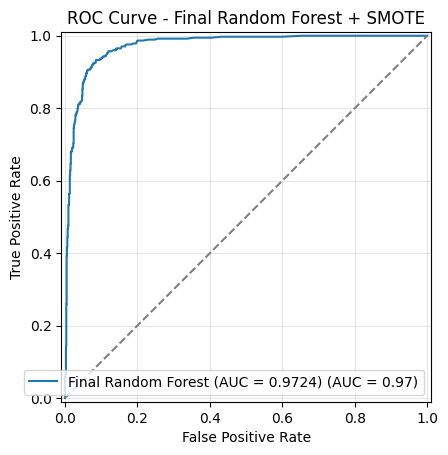

In [51]:
#ROC Curve untuk Final Random Forest
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_final,
    name=f"Final Random Forest (AUC = {roc_final:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve - Final Random Forest + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

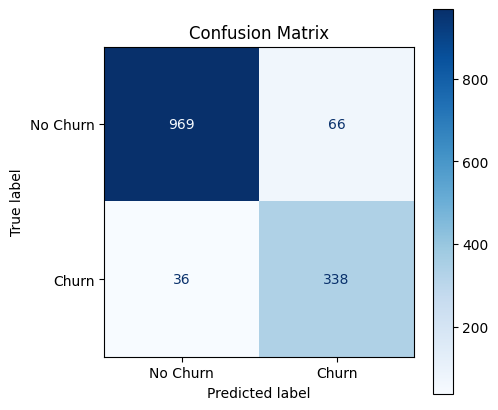

In [52]:
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [53]:
comparison_rf = pd.DataFrame({

    "Baseline RF": {
        "Accuracy": results_baseline["Random Forest"]["Accuracy"],
        "Precision": results_baseline["Random Forest"]["Precision"],
        "Recall": results_baseline["Random Forest"]["Recall"],
        "F1-Score": results_baseline["Random Forest"]["F1-Score"],
        "ROC-AUC": results_baseline["Random Forest"]["ROC-AUC"],
        "Train/Tuning Time (s)": results_baseline["Random Forest"]["Train Time (s)"],
        "Test Time (s)": results_baseline["Random Forest"]["Test Time (s)"]
    },

    "RF + SMOTE": {
        "Accuracy": results_smote["Random Forest"]["Accuracy"],
        "Precision": results_smote["Random Forest"]["Precision"],
        "Recall": results_smote["Random Forest"]["Recall"],
        "F1-Score": results_smote["Random Forest"]["F1-Score"],
        "ROC-AUC": results_smote["Random Forest"]["ROC-AUC"],
        "Train/Tuning Time (s)": results_smote["Random Forest"]["Train Time (s)"],
        "Test Time (s)": results_smote["Random Forest"]["Test Time (s)"]
    },

    "RF + SMOTE + GridSearch": {
        "Accuracy": rf_tuned_results["Accuracy"],
        "Precision": rf_tuned_results["Precision"],
        "Recall": rf_tuned_results["Recall"],
        "F1-Score": rf_tuned_results["F1-Score"],
        "ROC-AUC": rf_tuned_results["ROC-AUC"],
        "Train/Tuning Time (s)": rf_tuned_results["Tuning Time (s)"],
        "Test Time (s)": rf_tuned_results["Test Time (s)"]
    },

    "Final RF": {
        "Accuracy": final_rf_results["Accuracy"],
        "Precision": final_rf_results["Precision"],
        "Recall": final_rf_results["Recall"],
        "F1-Score": final_rf_results["F1-Score"],
        "ROC-AUC": final_rf_results["ROC-AUC"],
        "Train/Tuning Time (s)": final_rf_results["Tuning Time (s)"],
        "Test Time (s)": final_rf_results["Test Time (s)"]
    }}).T

#Bulatkan angka
comparison_rf = comparison_rf.round(4)

#Hasil
print("Perbandingan Random Forest")

display(comparison_rf)

Perbandingan Random Forest


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train/Tuning Time (s),Test Time (s)
Baseline RF,0.9297,0.8726,0.8610,0.8668,0.9719,3.0846,0.1173
RF + SMOTE,0.9262,0.8342,0.9011,0.8663,0.9710,5.3253,0.1151
RF + SMOTE + GridSearch,0.9262,0.8342,0.9011,0.8663,0.9710,331.4235,0.0512
Final RF,0.9276,0.8366,0.9037,0.8689,0.9724,251.4324,0.0298


#### Analisis Perbandingan Random Forest

- Model Baseline Random Forest sudah menunjukkan performa yang sangat baik dengan accuracy sebesar 92.97% dan F1-score sebesar 86.68%.

- Penerapan SMOTE berhasil meningkatkan recall dari 86.10% menjadi 90.11%, yang menunjukkan peningkatan kemampuan model dalam mendeteksi pelanggan churn.

- Peningkatan recall setelah SMOTE diikuti oleh penurunan precision, yang menunjukkan adanya trade-off akibat model menjadi lebih agresif dalam memprediksi churn.

- Hyperparameter tuning menggunakan GridSearchCV belum memberikan peningkatan performa yang signifikan, namun membutuhkan waktu tuning yang cukup lama.

- Final RF menghasilkan performa terbaik secara keseluruhan dengan accuracy sebesar 92.76%, recall sebesar 90.37%, F1-score sebesar 86.89%, dan ROC-AUC sebesar 0.9724.

- RF + RandomizedSearch menghasilkan recall tertinggi sebesar 90.64% dengan waktu tuning yang jauh lebih cepat dibandingkan GridSearchCV.

- RandomizedSearchCV terbukti lebih efisien dari sisi waktu komputasi karena mampu menghasilkan performa yang kompetitif dengan tuning time yang lebih singkat.

- Berdasarkan keseluruhan hasil evaluasi, Final Random Forest dipilih sebagai model terbaik karena memiliki performa klasifikasi paling seimbang dalam mendeteksi pelanggan churn.

# XAI 

Disini Memilih best Model untuk dilakukan XAI deployment nantinya. Dan XAI yang digunakan adalah SHAP. Jadi disini pakai Final_RF

In [54]:
explainer = shap.Explainer(best_final_rf, X_train)

In [55]:
joblib.dump(explainer, 'explainer.pkl')

['explainer.pkl']

In [56]:
#Ubah balik biar ga numpy array
feature_names = X.columns

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [57]:
explainer = shap.TreeExplainer(best_final_rf)

# Hitung SHAP values
shap_values = explainer.shap_values(X_test_df)

# Cek shape
print("SHAP Shape:", np.array(shap_values).shape)

SHAP Shape: (1409, 32, 2)


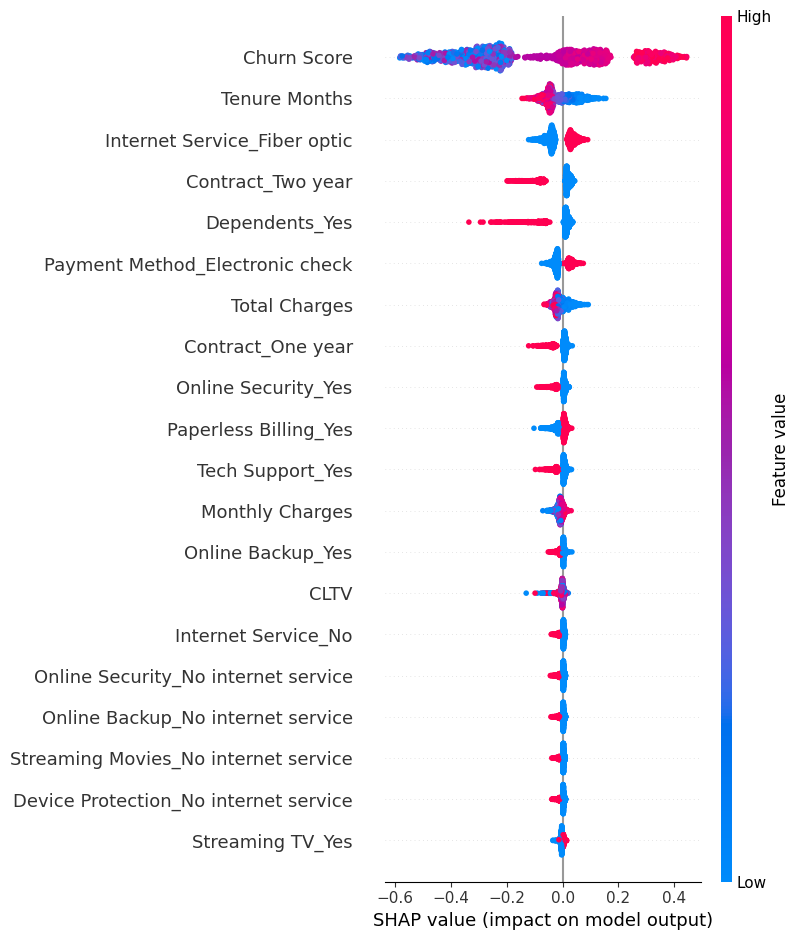

In [58]:
# =========================
# SHAP SUMMARY PLOT
# =========================

# Class 1 = Churn
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df
)

# =========================

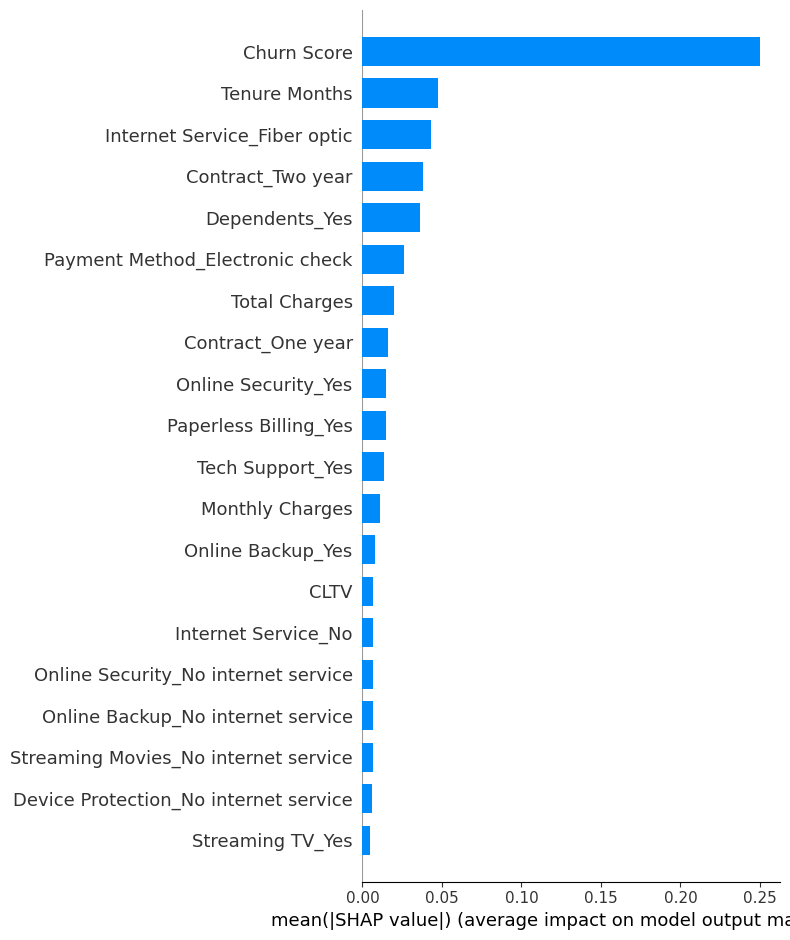

In [59]:
# SHAP FEATURE IMPORTANCE
# =========================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df,
    plot_type="bar"
)

100%|===================| 2811/2818 [02:15<00:00]        

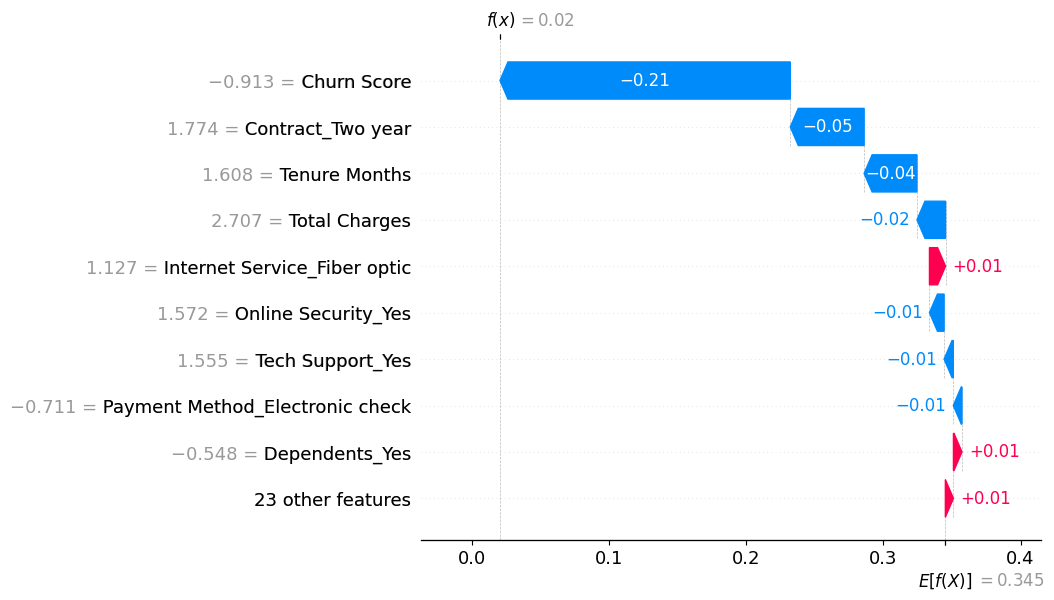

In [60]:
explainer = shap.Explainer(best_final_rf, X_train)

shap_values = explainer(
    X_test_df,
    check_additivity=False
)

# Waterfall Plot customer pertama
shap.plots.waterfall(
    shap_values[0, :, 1]
)

In [61]:
from datetime import datetime

now = datetime.now()
print(now)

2026-06-27 21:22:59.046902
